In [1]:
import ROOT
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import mplhep as hep
import tqdm
import os
import pandas

Welcome to JupyROOT 6.28/06


In [2]:
era = "2016APV"
postfix = "template_region_study" # postfix for save directory
rPath = "root://brux30.hep.brown.edu:1094//store/user/dali/"
#rPath = "root://cmseos.fnal.gov//store/user/dsunyou/"
rDir = rPath + "FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step3/nominal/".format( era )
nTree = "ljmet"

variables = [
    "NJetsPU_JetSubCalc",
    "thirdcsvb_bb",
    "NJetsCSV_JetSubCalc",
    "NJets_JetSubCalc",
    "ratio_HTdHT4leadjets",
    "BDTtrijet2",
    "HT_bjets",
    "fourthcsvb_bb",
    "AK4HT",
    "theJetLeadPt",
    "corr_met_MultiLepCalc",
    "secondcsvb_bb",
    "HOTGoodTrijet1_dRtrijetJetnotdijet",
    "theJetEtaAverage_JetSubCalc",
    "BJetLeadPt",
    "hemiout",
    "HT_2m",
    "mass_maxBBmass",
    "MT_lepMet",
    "secondJetPt",
    "BDTtrijet3",
    "M_allJet_W",
    "mass_maxJJJpt",
    "HOTGoodTrijet1_pTratio",
    "mass_lepBJet_mindr",
    "HOTGoodTrijet2_csvJetnotdijet",
    "BDTtrijet1",
    "centrality",
    "deltaR_lepBJet_maxpt",
    "FW_momentum_1",
    "MT2bb",
    "HOTGoodTrijet2_dRtrijetJetnotdijet",
    "mass_lepJets0",
    "HOTGoodTrijet2_dRtridijet",
    "Aplanarity",
    "deltaR_minBB",
    "aveBBdr",
    "FW_momentum_3",
    "csvJet4",
    "FW_momentum_4",
]

files = {
    "DATA": [
        "SingleElectron_hadd.root",
        #"EGamma_hadd.root",
        "SingleMuon_hadd.root"
    ],
    "MC": [
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_1_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_2_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_3_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_4_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_5_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_6_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_7_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_8_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_9_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_10_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root",
    ] 
}

lumimap = {
    "2016APV": "$19.52\ fb^{-1}$",
    "2016": "$16.81\ fb^{-1}$",
    "2017": "$41.48\ fb^{-1}$",
    "2018": "$59.83\ fb^{-1}$",
}

In [3]:
rDF = { "DATA": {}, "MC": {} }

fBase = "DataPastTriggerX == 1 && MCPastTriggerX == 1 && AK4HT > 450 && NJetsCSV_JetSubCalc >= 1"

for file_ in tqdm.tqdm( files[ "DATA" ] ):
    rDF["DATA"][file_] = ROOT.RDataFrame( nTree, rDir + file_ ).Filter( fBase ).AsNumpy( columns = variables )
for file_ in tqdm.tqdm( files[ "MC" ] ):
    rDF["MC"][file_] = ROOT.RDataFrame( nTree, rDir + file_ ).Filter( fBase ).AsNumpy( columns = variables )

100%|██████████| 15/15 [01:31<00:00,  6.13s/it]


In [4]:
data = { variable_: [] for variable_ in variables }
mc = { variable_: [] for variable_ in variables }

for variable_ in tqdm.tqdm( variables ):
    for file_ in rDF["DATA"]:
        data[variable_] = np.concatenate( ( data[variable_], rDF["DATA"][file_][variable_] ) )
    for file_ in rDF["MC"]:
        mc[variable_] = np.concatenate( ( mc[variable_], rDF["MC"][file_][variable_] ) )

100%|██████████| 40/40 [00:02<00:00, 17.90it/s]


In [5]:
data_pd = pandas.DataFrame.from_dict( data )
mc_pd = pandas.DataFrame.from_dict( mc )

In [6]:
data_pd

,NJetsPU_JetSubCalc,thirdcsvb_bb,NJetsCSV_JetSubCalc,NJets_JetSubCalc,ratio_HTdHT4leadjets,BDTtrijet2,HT_bjets,fourthcsvb_bb,AK4HT,theJetLeadPt,...,MT2bb,HOTGoodTrijet2_dRtrijetJetnotdijet,mass_lepJets0,HOTGoodTrijet2_dRtridijet,Aplanarity,deltaR_minBB,aveBBdr,FW_momentum_3,csvJet4,FW_momentum_4
0,2.0,0.005863,1.0,4.0,1.000000,0.179075,68.301781,0.005438,515.624634,235.552917,...,0.000000,0.0,218.026001,0.0,0.108781,20.000000,0.000000,0.416282,0.999310,0.217221
1,1.0,0.030484,1.0,8.0,1.460792,0.751635,146.790543,0.024777,846.471619,167.361954,...,20.802954,0.0,212.996765,0.0,0.083539,0.529948,2.035889,0.102469,0.024777,0.177707
2,0.0,0.009762,1.0,4.0,1.000000,-1.000000,144.717499,0.008105,511.544250,211.179398,...,60.785500,0.0,280.860962,0.0,0.003249,3.364843,4.537502,0.216397,0.008105,0.339217
3,0.0,0.040923,1.0,4.0,1.000000,-1.000000,0.000000,0.012819,520.966919,275.455231,...,0.000000,0.0,708.252380,0.0,0.000345,20.000000,0.000000,0.161642,0.283375,0.498943
4,1.0,0.006327,1.0,5.0,1.120413,-1.000000,106.348969,0.003236,516.323975,200.696442,...,21.710987,0.0,113.092216,0.0,0.005768,0.766475,2.460768,0.091210,0.037149,0.465478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194690,0.0,0.077778,2.0,4.0,1.000000,-1.000000,203.950043,0.059534,545.828735,277.428406,...,37.867561,0.0,318.375580,0.0,0.008158,1.716825,2.982942,0.212761,0.077778,0.466438
194691,0.0,0.023424,2.0,5.0,1.122782,-1.000000,154.511093,0.014648,458.154266,197.544891,...,37.996933,0.0,100.620407,0.0,0.038330,1.697323,2.742045,0.458296,0.013244,0.158539
194692,0.0,0.040017,2.0,4.0,1.000000,-1.000000,236.901962,0.011314,571.790222,213.222000,...,32.886288,0.0,410.952728,0.0,0.011947,3.109354,3.640186,0.659919,0.997213,0.663813
194693,0.0,0.005583,2.0,4.0,1.000000,-1.000000,215.216385,0.004899,515.503296,209.224014,...,97.058632,0.0,476.606201,0.0,0.006623,0.643258,1.276433,0.072016,0.005583,0.433791


In [7]:
mc_pd

,NJetsPU_JetSubCalc,thirdcsvb_bb,NJetsCSV_JetSubCalc,NJets_JetSubCalc,ratio_HTdHT4leadjets,BDTtrijet2,HT_bjets,fourthcsvb_bb,AK4HT,theJetLeadPt,...,MT2bb,HOTGoodTrijet2_dRtrijetJetnotdijet,mass_lepJets0,HOTGoodTrijet2_dRtridijet,Aplanarity,deltaR_minBB,aveBBdr,FW_momentum_3,csvJet4,FW_momentum_4
0,0.0,0.130194,1.0,4.0,1.000000,-1.000000,162.089310,0.005351,505.350800,217.988113,...,81.246803,0.0,139.144440,0.0,0.012030,0.453837,1.650376,0.231629,0.130194,0.449492
1,0.0,0.008030,1.0,5.0,1.129776,-1.000000,145.185532,0.004038,532.813843,145.185532,...,22.112915,0.0,87.663681,0.0,0.286503,1.420061,2.504632,0.111697,0.004038,0.315633
2,0.0,0.019749,1.0,4.0,1.000000,-1.000000,119.297630,0.004137,564.954041,279.417145,...,22.932772,0.0,313.553802,0.0,0.004514,3.123703,4.123703,0.385502,0.019749,0.238587
3,0.0,0.045153,2.0,4.0,1.000000,-1.000000,273.287445,0.002270,459.912781,239.751770,...,173.806610,0.0,337.054993,0.0,0.056531,0.483663,1.990171,0.551120,0.415392,0.416380
4,0.0,0.184358,2.0,4.0,1.000000,-1.000000,345.435577,0.029706,509.782990,190.131821,...,18.525949,0.0,334.477692,0.0,0.036085,0.780761,2.278701,0.264503,0.184358,0.299262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2439223,3.0,0.037862,2.0,5.0,1.209307,0.474765,254.004791,0.006283,622.715942,148.987366,...,59.569046,0.0,75.711731,0.0,0.060653,1.080574,2.404944,0.281853,0.006283,0.110925
2439224,0.0,0.016156,1.0,7.0,1.417542,0.698830,123.684250,0.010945,1036.945679,323.954376,...,46.958122,0.0,159.443146,0.0,0.157488,1.592452,2.837929,0.186737,0.004323,0.206766
2439225,1.0,0.020597,1.0,8.0,1.578876,0.046696,70.082001,0.019913,680.334167,153.404282,...,19.316158,0.0,191.994858,0.0,0.078469,2.577594,3.285268,0.085175,0.020597,0.104148
2439226,0.0,0.080654,2.0,6.0,1.212252,-1.000000,304.857971,0.003632,733.701111,233.393417,...,19.556551,0.0,146.174545,0.0,0.009205,1.786602,2.870977,0.143509,0.421283,0.181056


In [8]:
data_corr = data_pd.corr().to_numpy()
mc_corr = mc_pd.corr().to_numpy()

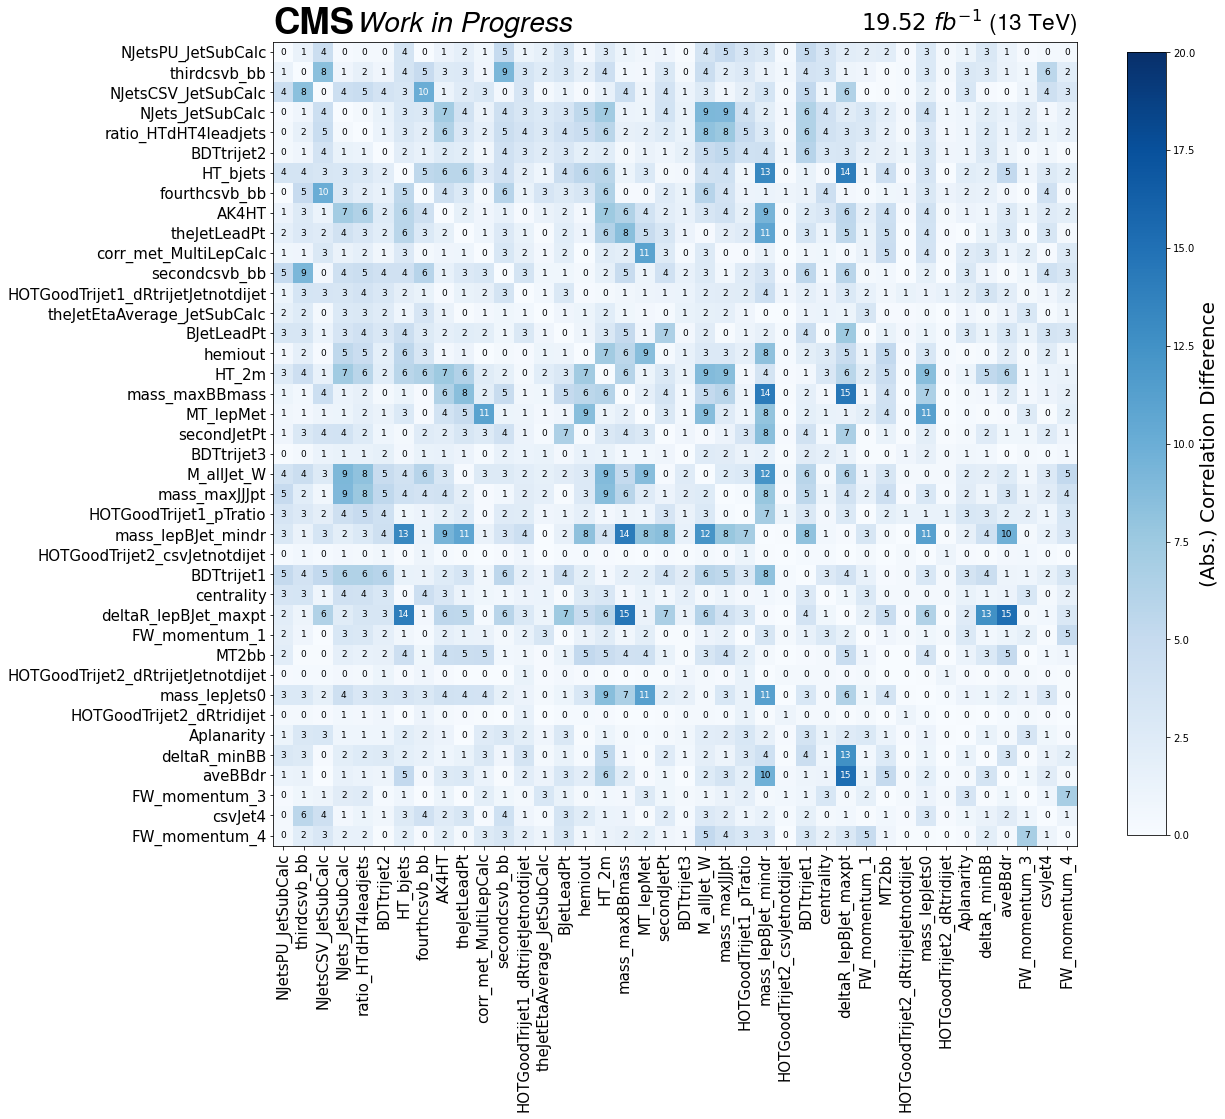

In [14]:
corr_diff = np.abs( data_corr - mc_corr ) * 100.

plt.figure( figsize = (18,18) )
hep.cms.text( "Work in Progress", fontsize = 28 )
hep.cms.lumitext( lumimap[era] + " (13 TeV)", fontsize = 24 )
plt.imshow( corr_diff, vmin = 0, vmax = 20, cmap = "Blues" ) 
plt.colorbar( shrink = 0.8 ).set_label( label = "(Abs.) Correlation Difference", size = 20 )
plt.xticks( ticks = range(40), labels = variables, rotation = 90, fontsize = 15 )
plt.yticks( ticks = range(40), labels = variables, fontsize = 15 )
for i in range(40):
    for j in range(40):
        color = "black" if corr_diff[i][j] < 10 else "white"
        plt.text( i, j, "{:.0f}".format( corr_diff[i][j] ), ha = "center", va = "center", fontsize = 9, color = color )
plt.show()
plt.close()

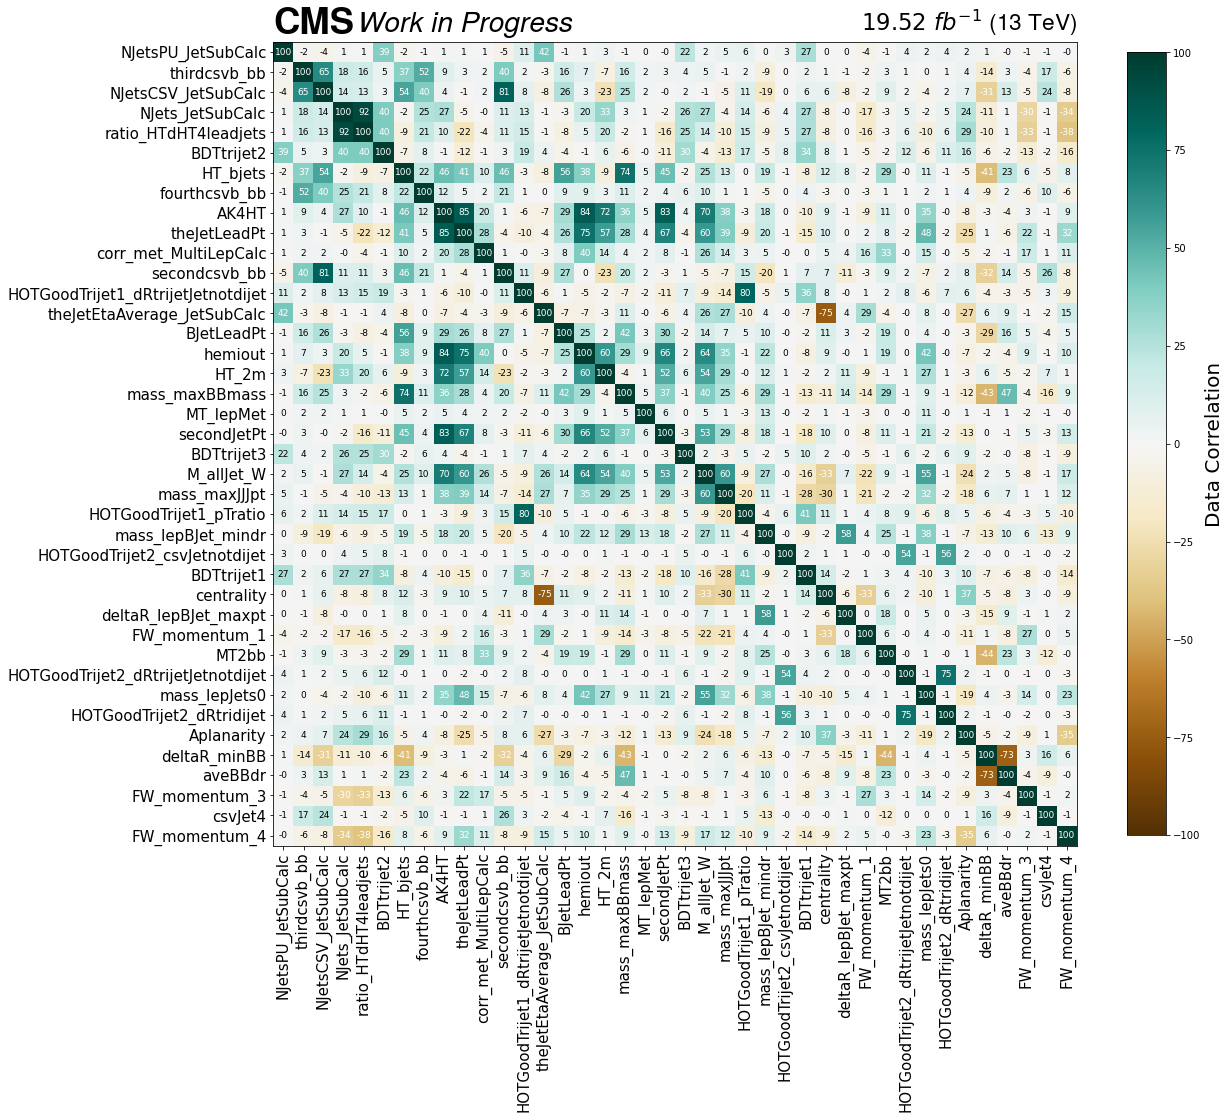

In [20]:
plt.figure( figsize = (18,18) )
hep.cms.text( "Work in Progress", fontsize = 28 )
hep.cms.lumitext( lumimap[era] + " (13 TeV)", fontsize = 24 )
plt.imshow( data_corr * 100., vmin = -100, vmax = 100, cmap = "BrBG" ) 
plt.colorbar( shrink = 0.8 ).set_label( label = "Data Correlation", size = 20 )
plt.xticks( ticks = range(40), labels = variables, rotation = 90, fontsize = 15 )
plt.yticks( ticks = range(40), labels = variables, fontsize = 15 )
for i in range(40):
    for j in range(40):
        color = "black" if abs( data_corr[i][j] ) < 0.3 else "white"
        plt.text( i, j, "{:.0f}".format( 100. * data_corr[i][j] ), ha = "center", va = "center", fontsize = 9, color = color )
plt.show()
plt.close()

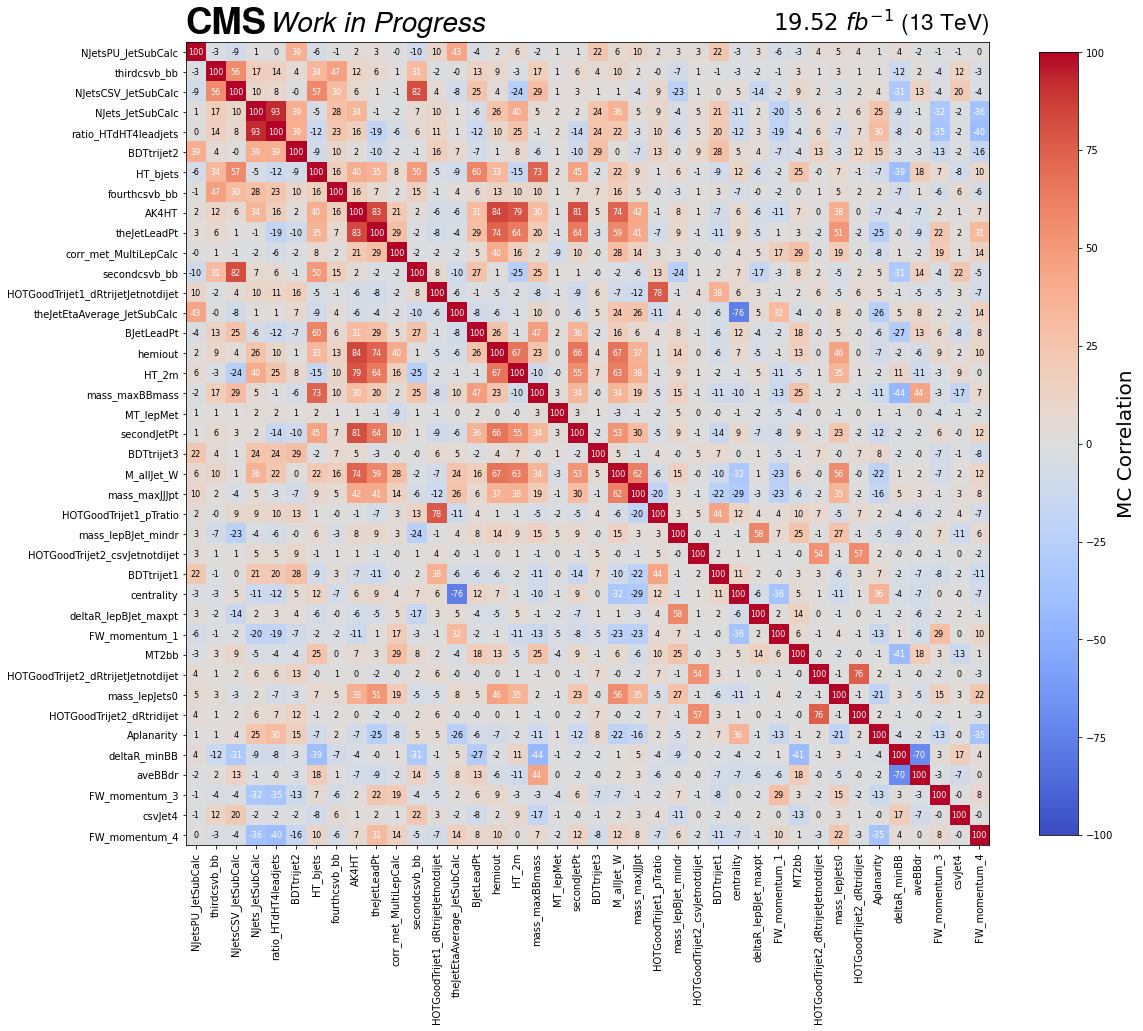

In [11]:
plt.figure( figsize = (18,18) )
hep.cms.text( "Work in Progress", fontsize = 28 )
hep.cms.lumitext( lumimap[era] + " (13 TeV)", fontsize = 24 )
plt.imshow( mc_corr * 100., vmin = -100, vmax = 100, cmap = "coolwarm" ) 
plt.colorbar( shrink = 0.8 ).set_label( label = "MC Correlation", size = 20 )
plt.xticks( ticks = range(40), labels = variables, rotation = 90 )
plt.yticks( ticks = range(40), labels = variables )
for i in range(40):
    for j in range(40):
        color = "black" if abs( mc_corr[i][j] ) < 0.3 else "white"
        plt.text( i, j, "{:.0f}".format( 100. * mc_corr[i][j] ), ha = "center", va = "center", fontsize = 8, color = color )
plt.show()
plt.close()